## Comparing the CFLIB original FITS plot and Interpolator plot 

In [1]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt 
from astropy.io import fits 

%matplotlib inline

In [2]:
path249 = "../FITS_data/249.fits"

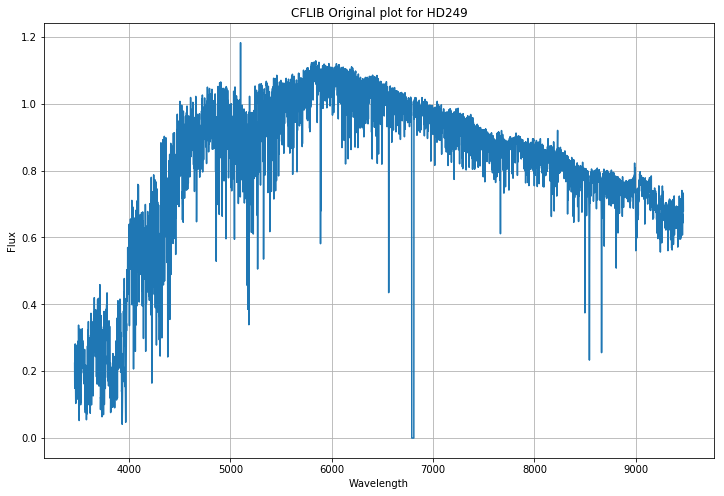

In [21]:
with fits.open(path249) as data_249:
    hdr = data_249[0].header
    
    crval = hdr["CRVAL1"]      # start value of the wavelength pixel
    cdelt = hdr["CDELT1"]      # step value of the wavelength pixel 

    n_wave_points = len(data_249[0].data)

    wavelength = crval + cdelt * np.arange(n_wave_points)

    flux = data_249[0].data

    plt.figure(figsize= (12, 8))
    plt.grid()
    plt.title("CFLIB Original plot for HD249")
    plt.xlabel("Wavelength")
    plt.ylabel("Flux")
    plt.plot(wavelength,flux)
    plt.show()



Plotting the Random Forest Interpolator flux wavelength continuum : 

In [8]:
df = pd.read_csv("asu (2).tsv", delimiter = "\t", encoding = "latin1")

Getting the atmospheric parameters for the HD000249 star

In [10]:
df[df["Name"] == b'HD000249  ']

,n_Name,Name,SpType,Teff,e_Teff,log(g),e_log(g),[Fe/H],e_[Fe/H],r_[Fe/H],SimbadName,_RA,_DE
2,,HD000249,K1IV,4757,28,2.88,0.09,-0.29,0.06,0,HD000249,001.84401,+26.45060


### Using the Interpolator: 

In [11]:
INTERPOLATOR_MODEL = 'RF_base_model_pvk.sav'
STANDARD_SCALER = 'rf_standard_scale_pvk.sav'

In [12]:
from sklearn.externals import joblib

sc = joblib.load(STANDARD_SCALER)
ip = joblib.load(INTERPOLATOR_MODEL)

/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/base.py:311: UserWarning: Trying to unpickle estimator StandardScaler from version 0.20.2 when using version 0.19.1. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)
/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/ensemble/weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d
/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7/site-packages/sklearn/base.py:311: UserWarning: Trying to unpickle estimator DecisionTreeRegressor from version 0.20.2 when using version 0.19.1. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)
/home/arbiter/projects2/Recalibration-deep-learning/venv27/lib/python2.7

In [13]:
ip.n_jobs = 1 

def InterpolateSpectrum(temperature, gravity, metallicity):
    X = np.array([temperature, gravity, metallicity]).reshape(1, -1)
    X_std = sc.transform(X)
    y = ip.predict(X_std)
    return y

Putting the parameters for the HD249 star in the interpolator

In [14]:
pred = InterpolateSpectrum(4757,2.88,-0.29)

In [27]:
wave = 3500. + np.arange(4306, dtype=np.float)*0.4

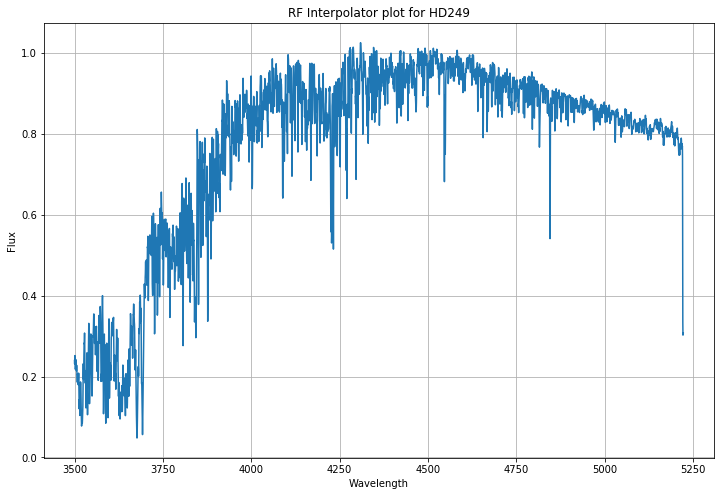

In [28]:
plt.figure(figsize=(12,8))
plt.plot(wave,pred[0,:])
plt.title("RF Interpolator plot for HD249")
plt.ylabel("Flux")
plt.xlabel("Wavelength")
plt.grid()
plt.show()

Comparing the Interpolator continuum curve and original CFLIB curve for the HD000249 star : 

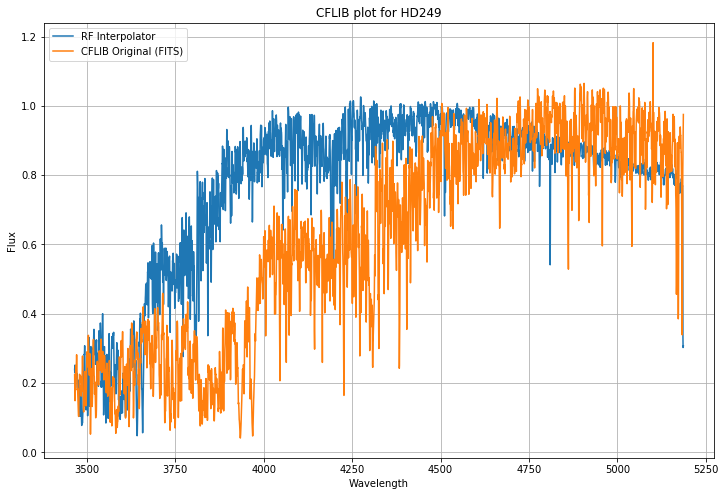

In [33]:
with fits.open(path249) as data_249:
    hdr = data_249[0].header
    
    crval = hdr["CRVAL1"]      # start value of the wavelength pixel
    cdelt = hdr["CDELT1"]      # step value of the wavelength pixel 

    n_wave_points = len(data_249[0].data)
    

    wavelength = crval + cdelt * np.arange(4306)

    flux = data_249[0].data[:4306]

    plt.figure(figsize= (12, 8))
    plt.grid()
    plt.title("CFLIB plot for HD249")
    plt.xlabel("Wavelength")
    plt.ylabel("Flux")
    plt.plot(wavelength, pred[0,:], label = "RF Interpolator")
    plt.plot(wavelength,flux, label = "CFLIB Original (FITS)")
    plt.legend()
    plt.show()